### Библиотеки

In [1]:
import sys
sys.path.append('../data')
sys.path.append('../src')

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

import boto3
import io
from dotenv import dotenv_values
config = dotenv_values("../.env")

import warnings
warnings.filterwarnings("ignore")

### Данные

In [2]:
session = boto3.session.Session()
s3 = session.client(
    service_name='s3',
    endpoint_url='https://storage.yandexcloud.net',
    aws_access_key_id = config['AWS_ACCESS_KEY_ID'],
    aws_secret_access_key = config['AWS_SECRET_ACCESS_KEY']
)

In [3]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/work_df.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
work_df = pd.read_csv(csv_data)

work_df['Timestamp'] = pd.to_datetime(work_df['Timestamp'])
work_df = work_df.set_index('Timestamp')
work_df

,not_working_day
Timestamp,
2017-01-09,0.0
2017-01-10,0.0
2017-01-11,0.0
2017-01-12,0.0
2017-01-13,0.0
...,...
2021-03-27,1.0
2021-03-28,1.0
2021-03-29,0.0


In [4]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/rate_usa.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
rate_usa = pd.read_csv(csv_data)

rate_usa['Timestamp'] = pd.to_datetime(rate_usa['Date'])
rate_usa = rate_usa.set_index('Timestamp').drop(columns=['Date'], axis=1)
rate_usa

,rate_usa
Timestamp,
1950-01-01,1.5
1950-01-02,1.5
1950-01-03,1.5
1950-01-04,1.5
1950-01-05,1.5
...,...
2024-01-27,5.5
2024-01-28,5.5
2024-01-29,5.5


In [5]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/exchange_usd.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
exchange_usd = pd.read_csv(csv_data)

exchange_usd['Timestamp'] = pd.to_datetime(exchange_usd['Date'])
exchange_usd = exchange_usd.set_index('Timestamp').drop(columns=['Date'], axis=1)
exchange_usd

,usd
Timestamp,
2017-01-10,59.8961
2017-01-11,59.9533
2017-01-12,60.1614
2017-01-13,59.4978
2017-01-14,59.3700
...,...
2021-03-27,75.7576
2021-03-28,75.8287
2021-03-29,75.8287


In [6]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/exchange_eur.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
exchange_eur = pd.read_csv(csv_data)

exchange_eur['Timestamp'] = pd.to_datetime(exchange_eur['Date'])
exchange_eur = exchange_eur.set_index('Timestamp').drop(columns=['Date'], axis=1)
exchange_eur

,eur
Timestamp,
2017-01-10,63.1125
2017-01-11,63.5445
2017-01-12,63.5184
2017-01-13,63.2759
2017-01-14,63.1222
...,...
2021-03-27,89.2576
2021-03-28,89.3490
2021-03-29,89.3490


In [7]:
bytes_data = s3.get_object(Bucket='balance-predictions', Key="features/rate_russ.csv")['Body'].read()

csv_data = io.StringIO(str(bytes_data,'utf-8')) 
rate_russ = pd.read_csv(csv_data)

rate_russ['Timestamp'] = pd.to_datetime(rate_russ['Date'])
rate_russ = rate_russ.set_index('Timestamp').drop(columns=['Date'], axis=1)
rate_russ['rate_russ']

Timestamp
2017-01-01    10.0
2017-01-02    10.0
2017-01-03    10.0
2017-01-04    10.0
2017-01-05    10.0
              ... 
2021-11-27     8.5
2021-11-28     8.5
2021-11-29     8.5
2021-11-30     8.5
2021-12-01     8.5
Name: rate_russ, Length: 1796, dtype: float64

In [8]:
raw_data = pd.read_excel('../data/Project 2_2023.xlsx', sheet_name='Data')
raw_data = raw_data.rename(columns={'Date':'Timestamp'})
raw_data['Timestamp'] = pd.to_datetime(raw_data['Timestamp'])
raw_data = raw_data.set_index('Timestamp')
raw_data = raw_data.asfreq('D')
raw_data = raw_data.fillna(0)
raw_data

,Income,Outcome,Balance
Timestamp,,,
2017-01-09,1.343028,1.487865,-0.144836
2017-01-10,1.068610,1.194182,-0.125572
2017-01-11,0.944429,0.936663,0.007767
2017-01-12,1.672202,0.875379,0.796823
2017-01-13,0.955924,0.975645,-0.019721
...,...,...,...
2021-03-27,0.000000,0.000000,0.000000
2021-03-28,0.000000,0.000000,0.000000
2021-03-29,2.356883,3.370738,-1.013855


In [9]:
raw_data = pd.merge(raw_data, rate_usa, right_index=True, left_index=True, how='left')
raw_data = pd.merge(raw_data, rate_russ, right_index=True, left_index=True, how='left')
raw_data = pd.merge(raw_data, exchange_eur, right_index=True, left_index=True, how='left')
raw_data = pd.merge(raw_data, exchange_usd, right_index=True, left_index=True, how='left')
raw_data = pd.merge(raw_data, work_df, right_index=True, left_index=True, how='left')
raw_data = raw_data[raw_data['not_working_day'] == 0].bfill()
raw_data

,Income,Outcome,Balance,rate_usa,rate_russ,real_inflation,target_inflation,eur,usd,not_working_day
Timestamp,,,,,,,,,,
2017-01-09,1.343028,1.487865,-0.144836,1.25,10.0,4.6,4.0,63.1125,59.8961,0.0
2017-01-10,1.068610,1.194182,-0.125572,1.25,10.0,4.6,4.0,63.1125,59.8961,0.0
2017-01-11,0.944429,0.936663,0.007767,1.25,10.0,4.6,4.0,63.5445,59.9533,0.0
2017-01-12,1.672202,0.875379,0.796823,1.25,10.0,4.6,4.0,63.5184,60.1614,0.0
2017-01-13,0.955924,0.975645,-0.019721,1.25,10.0,4.6,4.0,63.2759,59.4978,0.0
...,...,...,...,...,...,...,...,...,...,...
2021-03-25,2.304215,3.173234,-0.869018,0.25,5.0,5.5,4.0,90.0515,76.1535,0.0
2021-03-26,2.172546,4.687433,-2.514887,0.25,5.0,5.5,4.0,89.9768,76.1741,0.0
2021-03-29,2.356883,3.370738,-1.013855,0.25,5.0,5.5,4.0,89.3490,75.8287,0.0


### Непрерывные показатели

Для выявления аномалий будем использовать скользяция окна, если наблюдение выпадает за диапазон, то сигнали0ируем о этом

In [10]:
def plotMovingAverage(series, n):
    
    """
    series - dataframe with timeseries
    n - rolling window size 
    
    """
    
    rolling_mean = series.rolling(window=n).mean().shift(1)
    rolling_std =  series.rolling(window=n).std().shift(1)
    upper_bond = rolling_mean+1.96*rolling_std
    lower_bond = rolling_mean-1.96*rolling_std
    
    plt.figure(figsize=(15,5))
    plt.title("Moving average\n window size = {}".format(n))
    plt.plot(rolling_mean, "g", label="Rolling mean trend")
    
    plt.plot(upper_bond, "r--", label="Upper Bond / Lower Bond")
    plt.plot(lower_bond, "r--")
    plt.plot(series[n+1:], label="Actual values")
    plt.legend(loc="upper left")
    plt.grid(True)

In [11]:
def MovingAverageAnomaly(val, series, n=20):
    
    """
    series - dataframe with timeseries
    n - rolling window size 
    
    """
    
    rolling_mean = series.rolling(window=n).mean()
    rolling_std =  series.rolling(window=n).std()
    upper_bond = rolling_mean+1.96*rolling_std
    lower_bond = rolling_mean-1.96*rolling_std

    if (val <= lower_bond[-1]) or (val >= upper_bond[-1]):
        return True
    else:
        return False

In [12]:
MovingAverageAnomaly(1.7, raw_data['Income'])

False

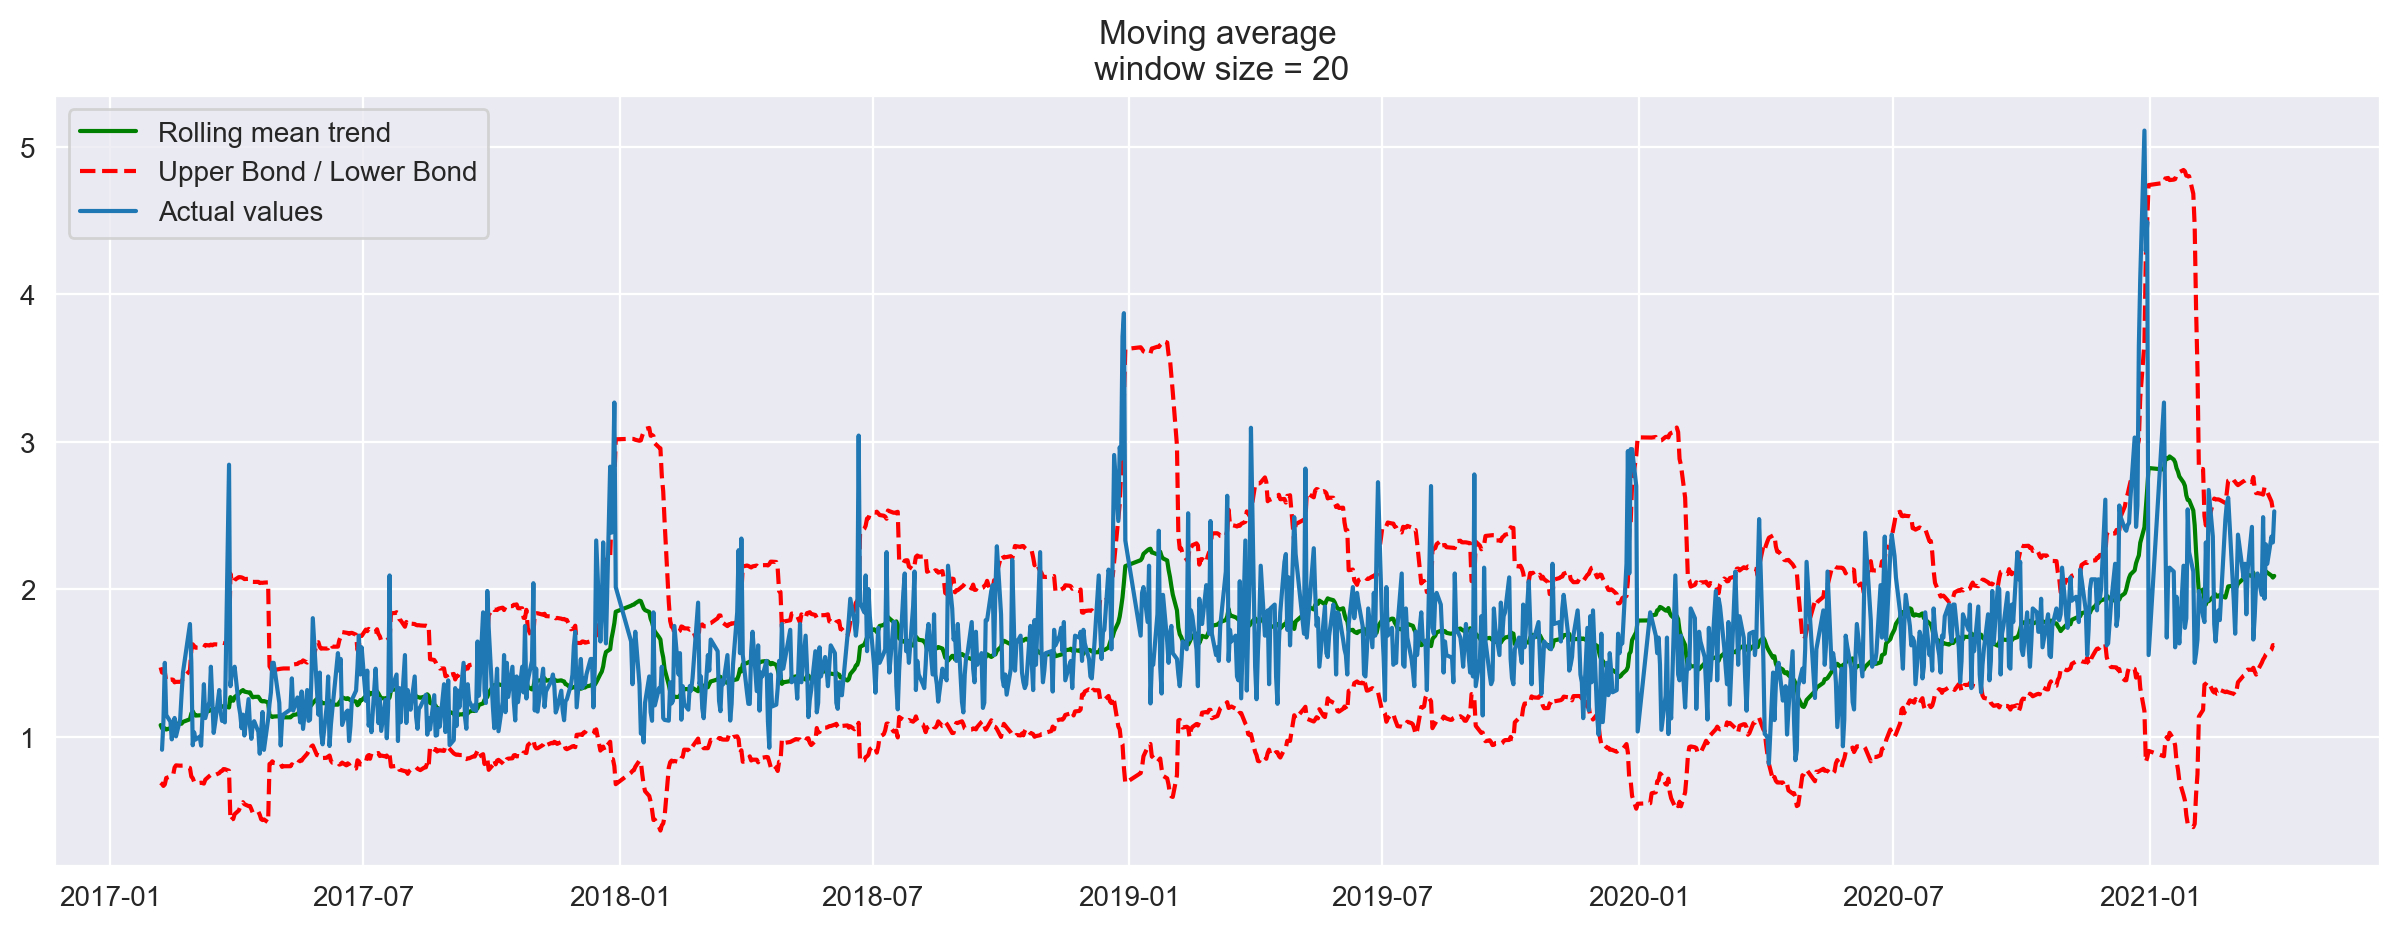

In [13]:
plotMovingAverage(raw_data['Income'], n=20)

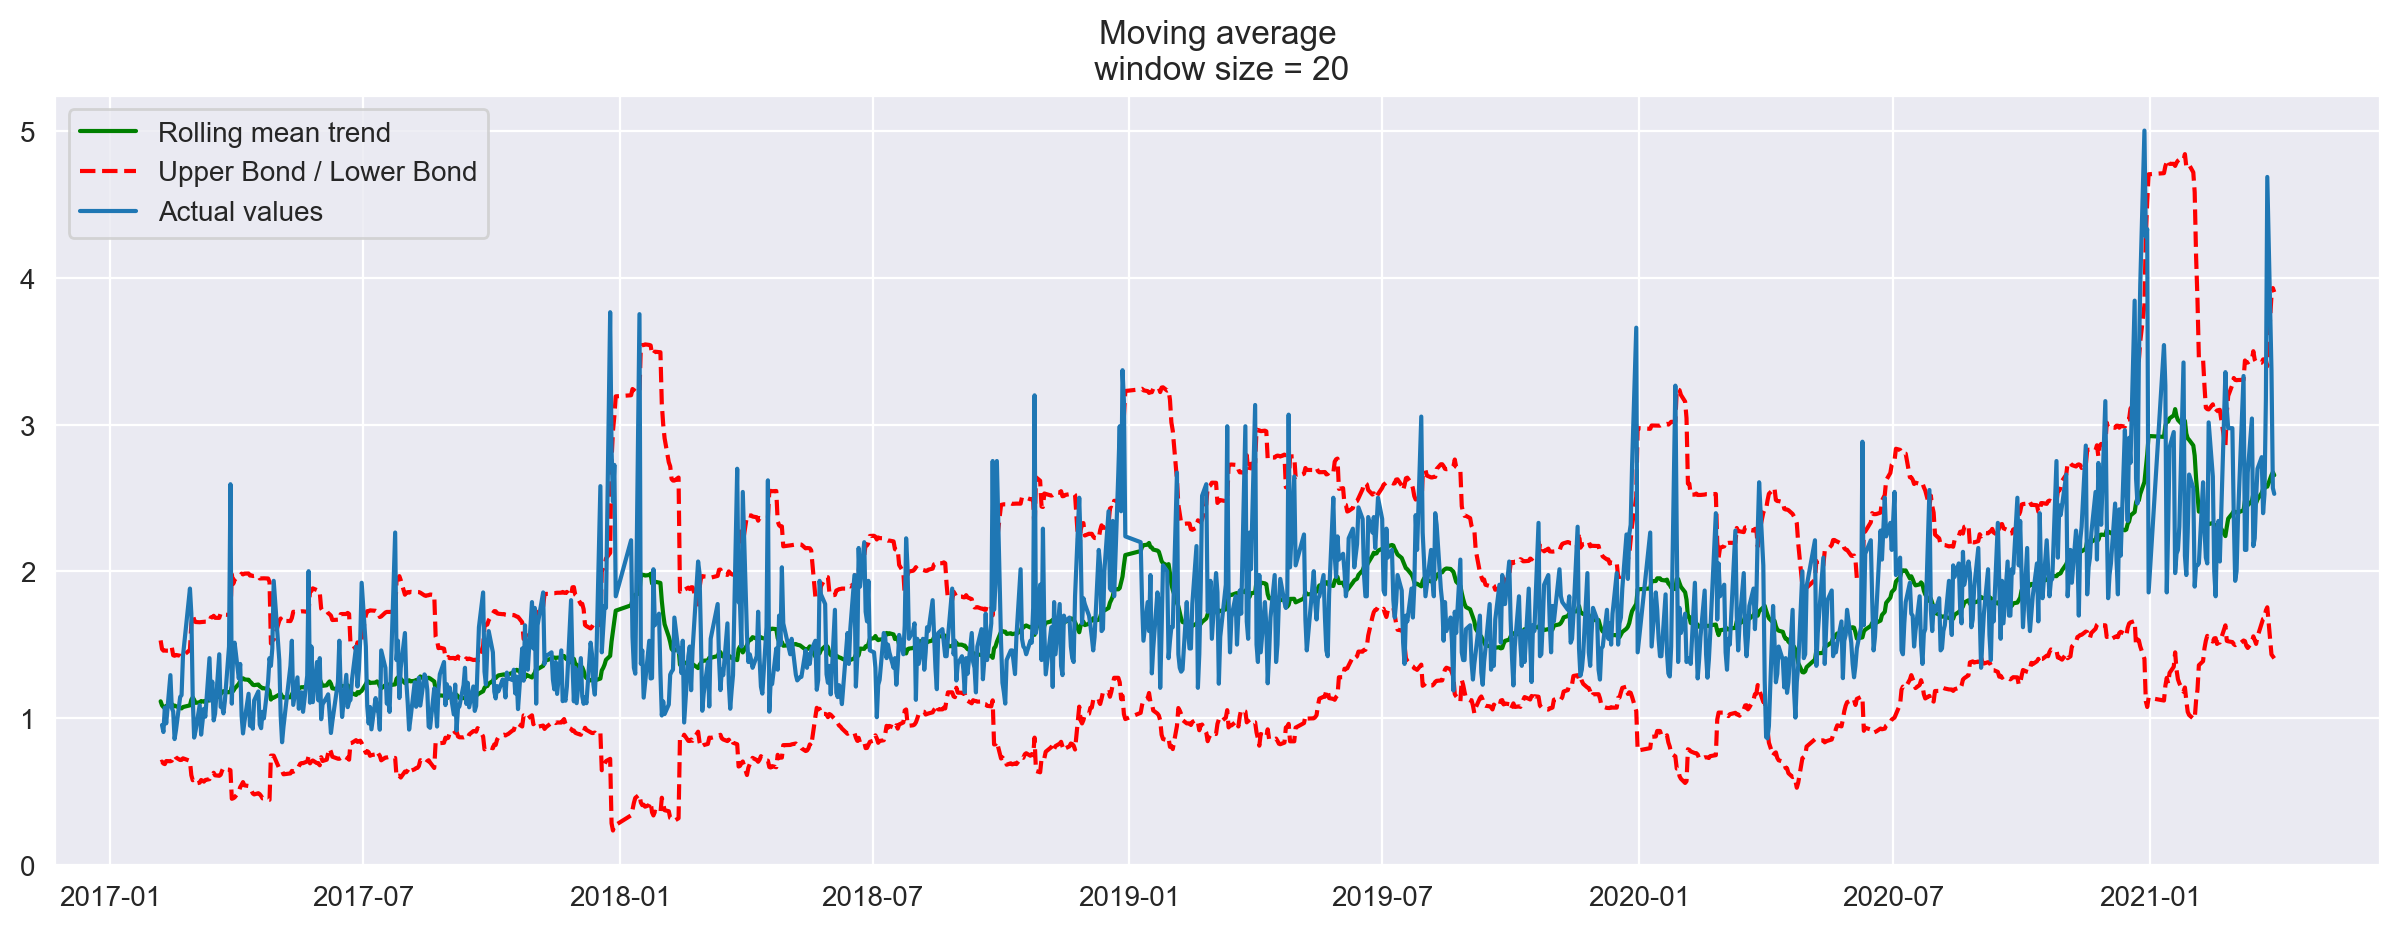

In [14]:
plotMovingAverage(raw_data['Outcome'], n=20)

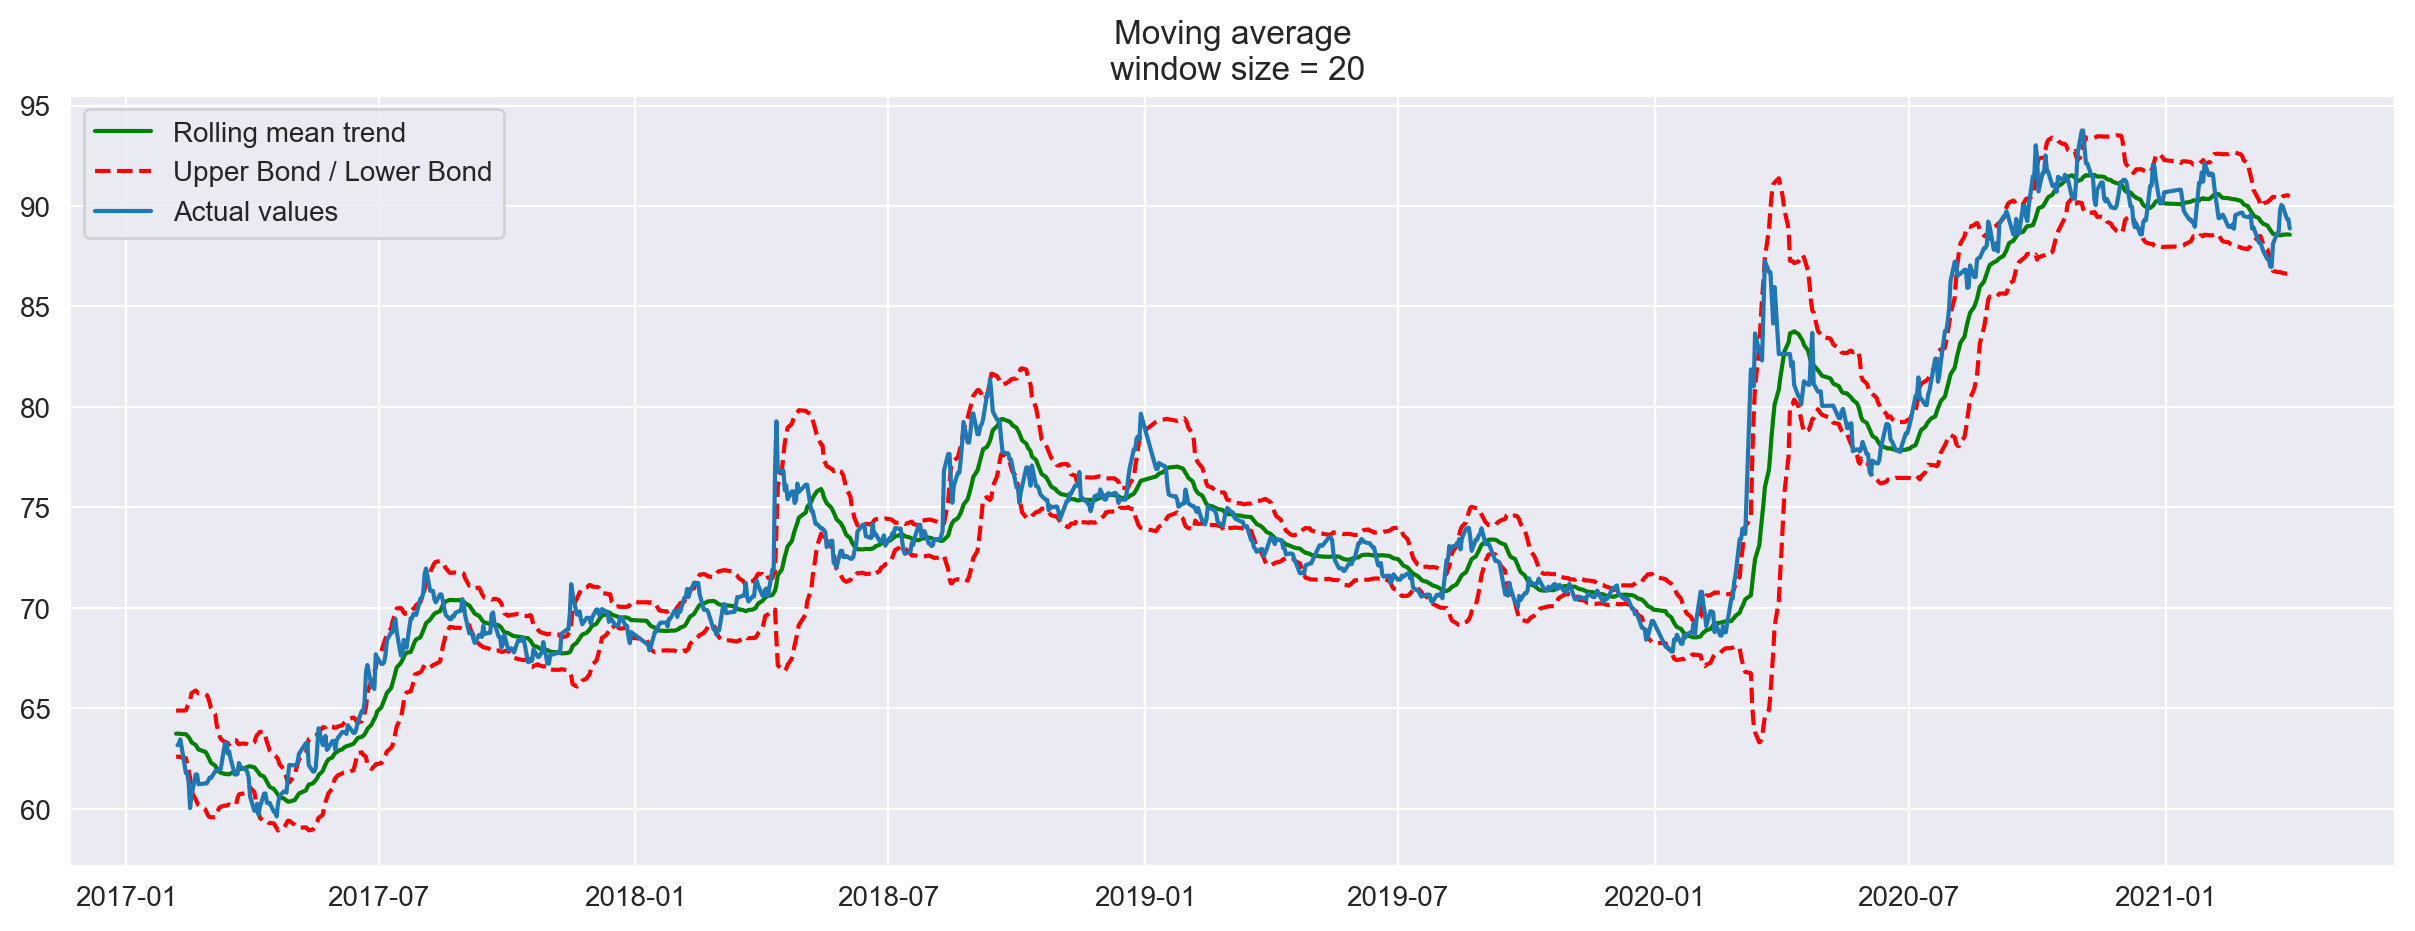

In [15]:
plotMovingAverage(raw_data['eur'], n=20)

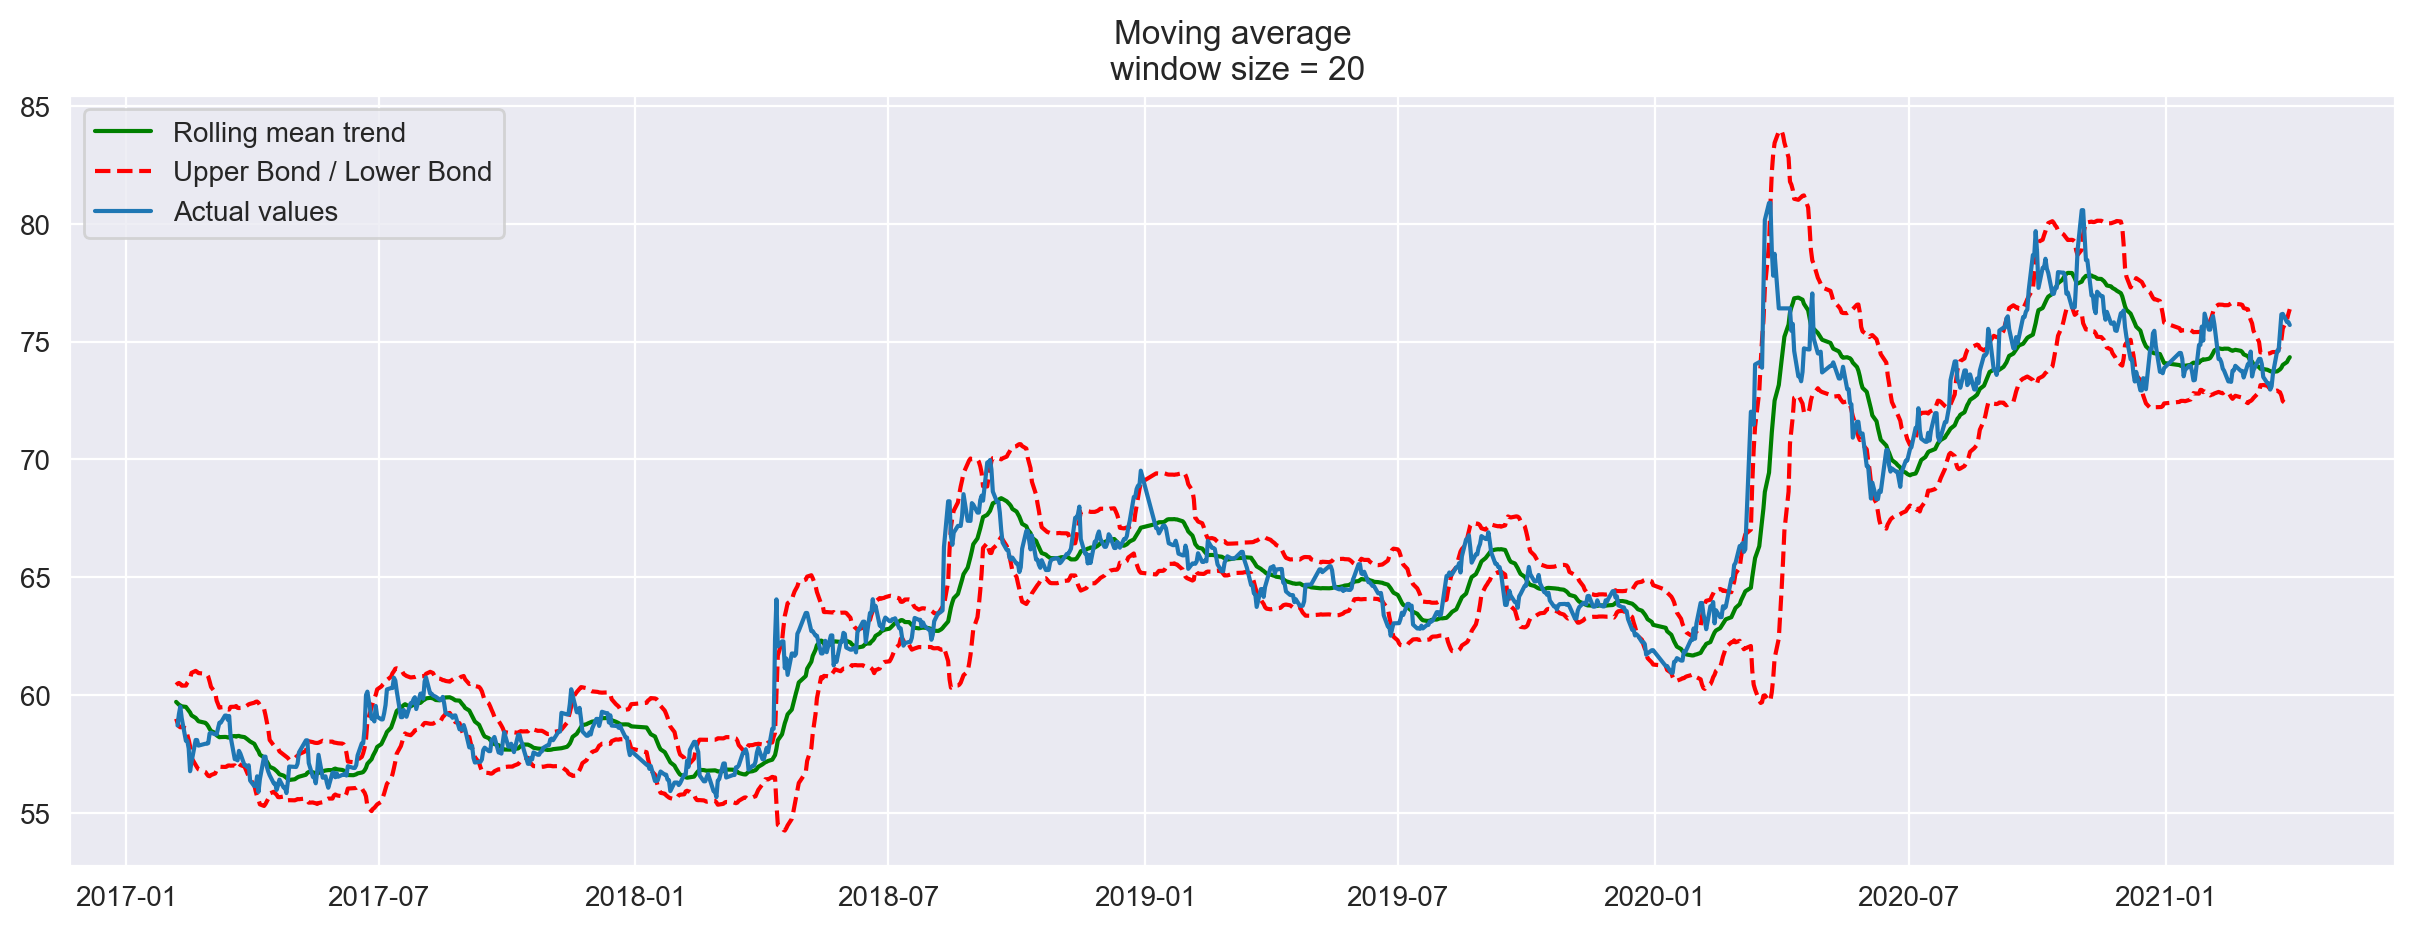

In [16]:
plotMovingAverage(raw_data['usd'], n=20)

### Ставки

Так как ставки меняются редко, то мы не можем также оценивать аномалии. Поэтому заданим пороги. Если ставка изменилась больше, чем на этот порог, за 1 день, то передаем на ручное управление. Реакция на изменение ключевой стваки сильно непредсказуема

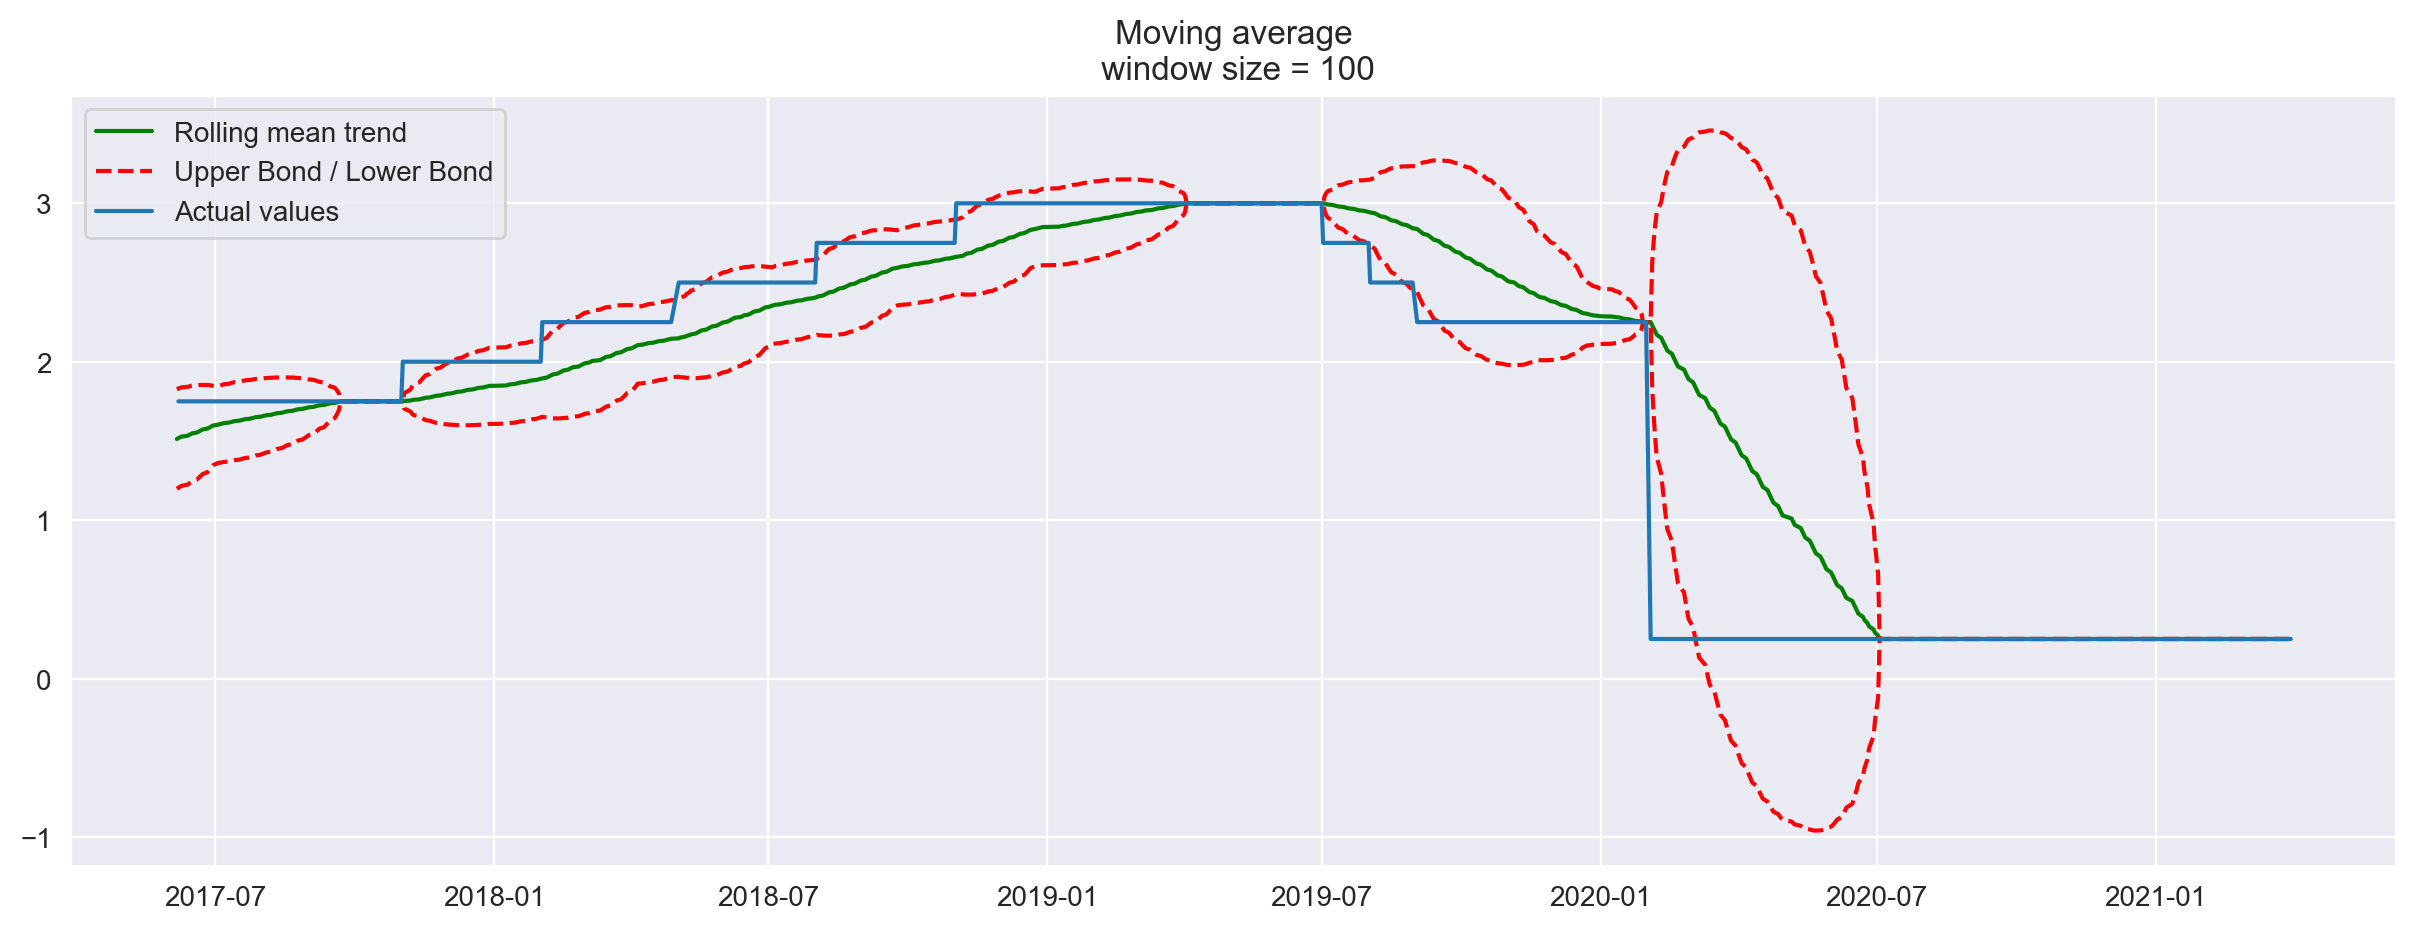

In [17]:
plotMovingAverage(raw_data['rate_usa'], n=100)

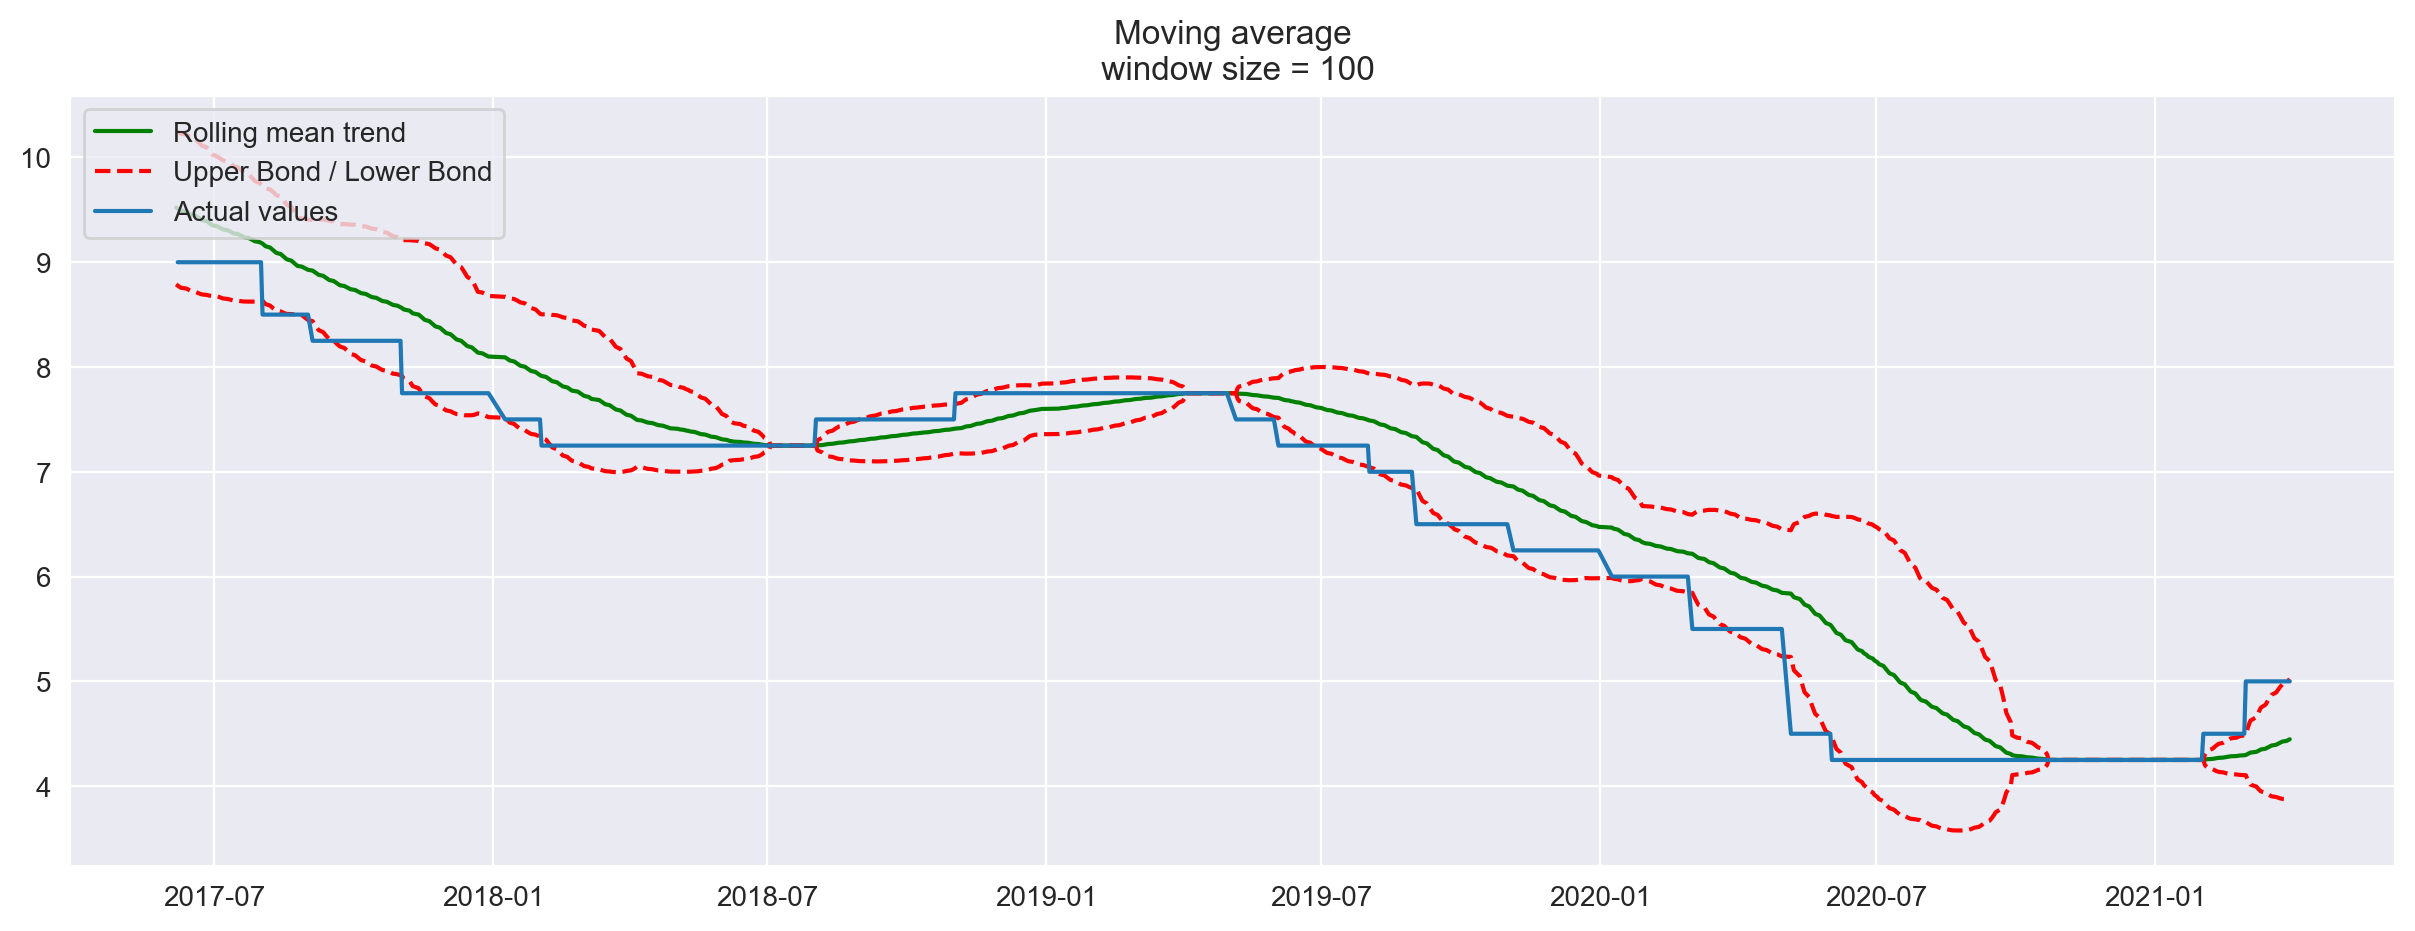

In [18]:
plotMovingAverage(raw_data['rate_russ'], n=100)